In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1894783          1                      16                        8   
1   1883785          0                       1                       21   
2   1741000          1                       9                        3   
3  39119945          1                       5                        6   
4  30579330          0                      13                        6   

   team0_team_total_networth  team0_team_total_damage  \
0                      36572                    21358   
1                      21242                    13837   
2                      33547                    21566   
3                      41388                    14982   
4                      35024                    17588   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             10671              8.666667   
1                              1073              7.000000   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    9303
0    9171
Name: count, dtype: int64
team0_won
1    0.503573
0    0.496427
Name: proportion, dtype: float64


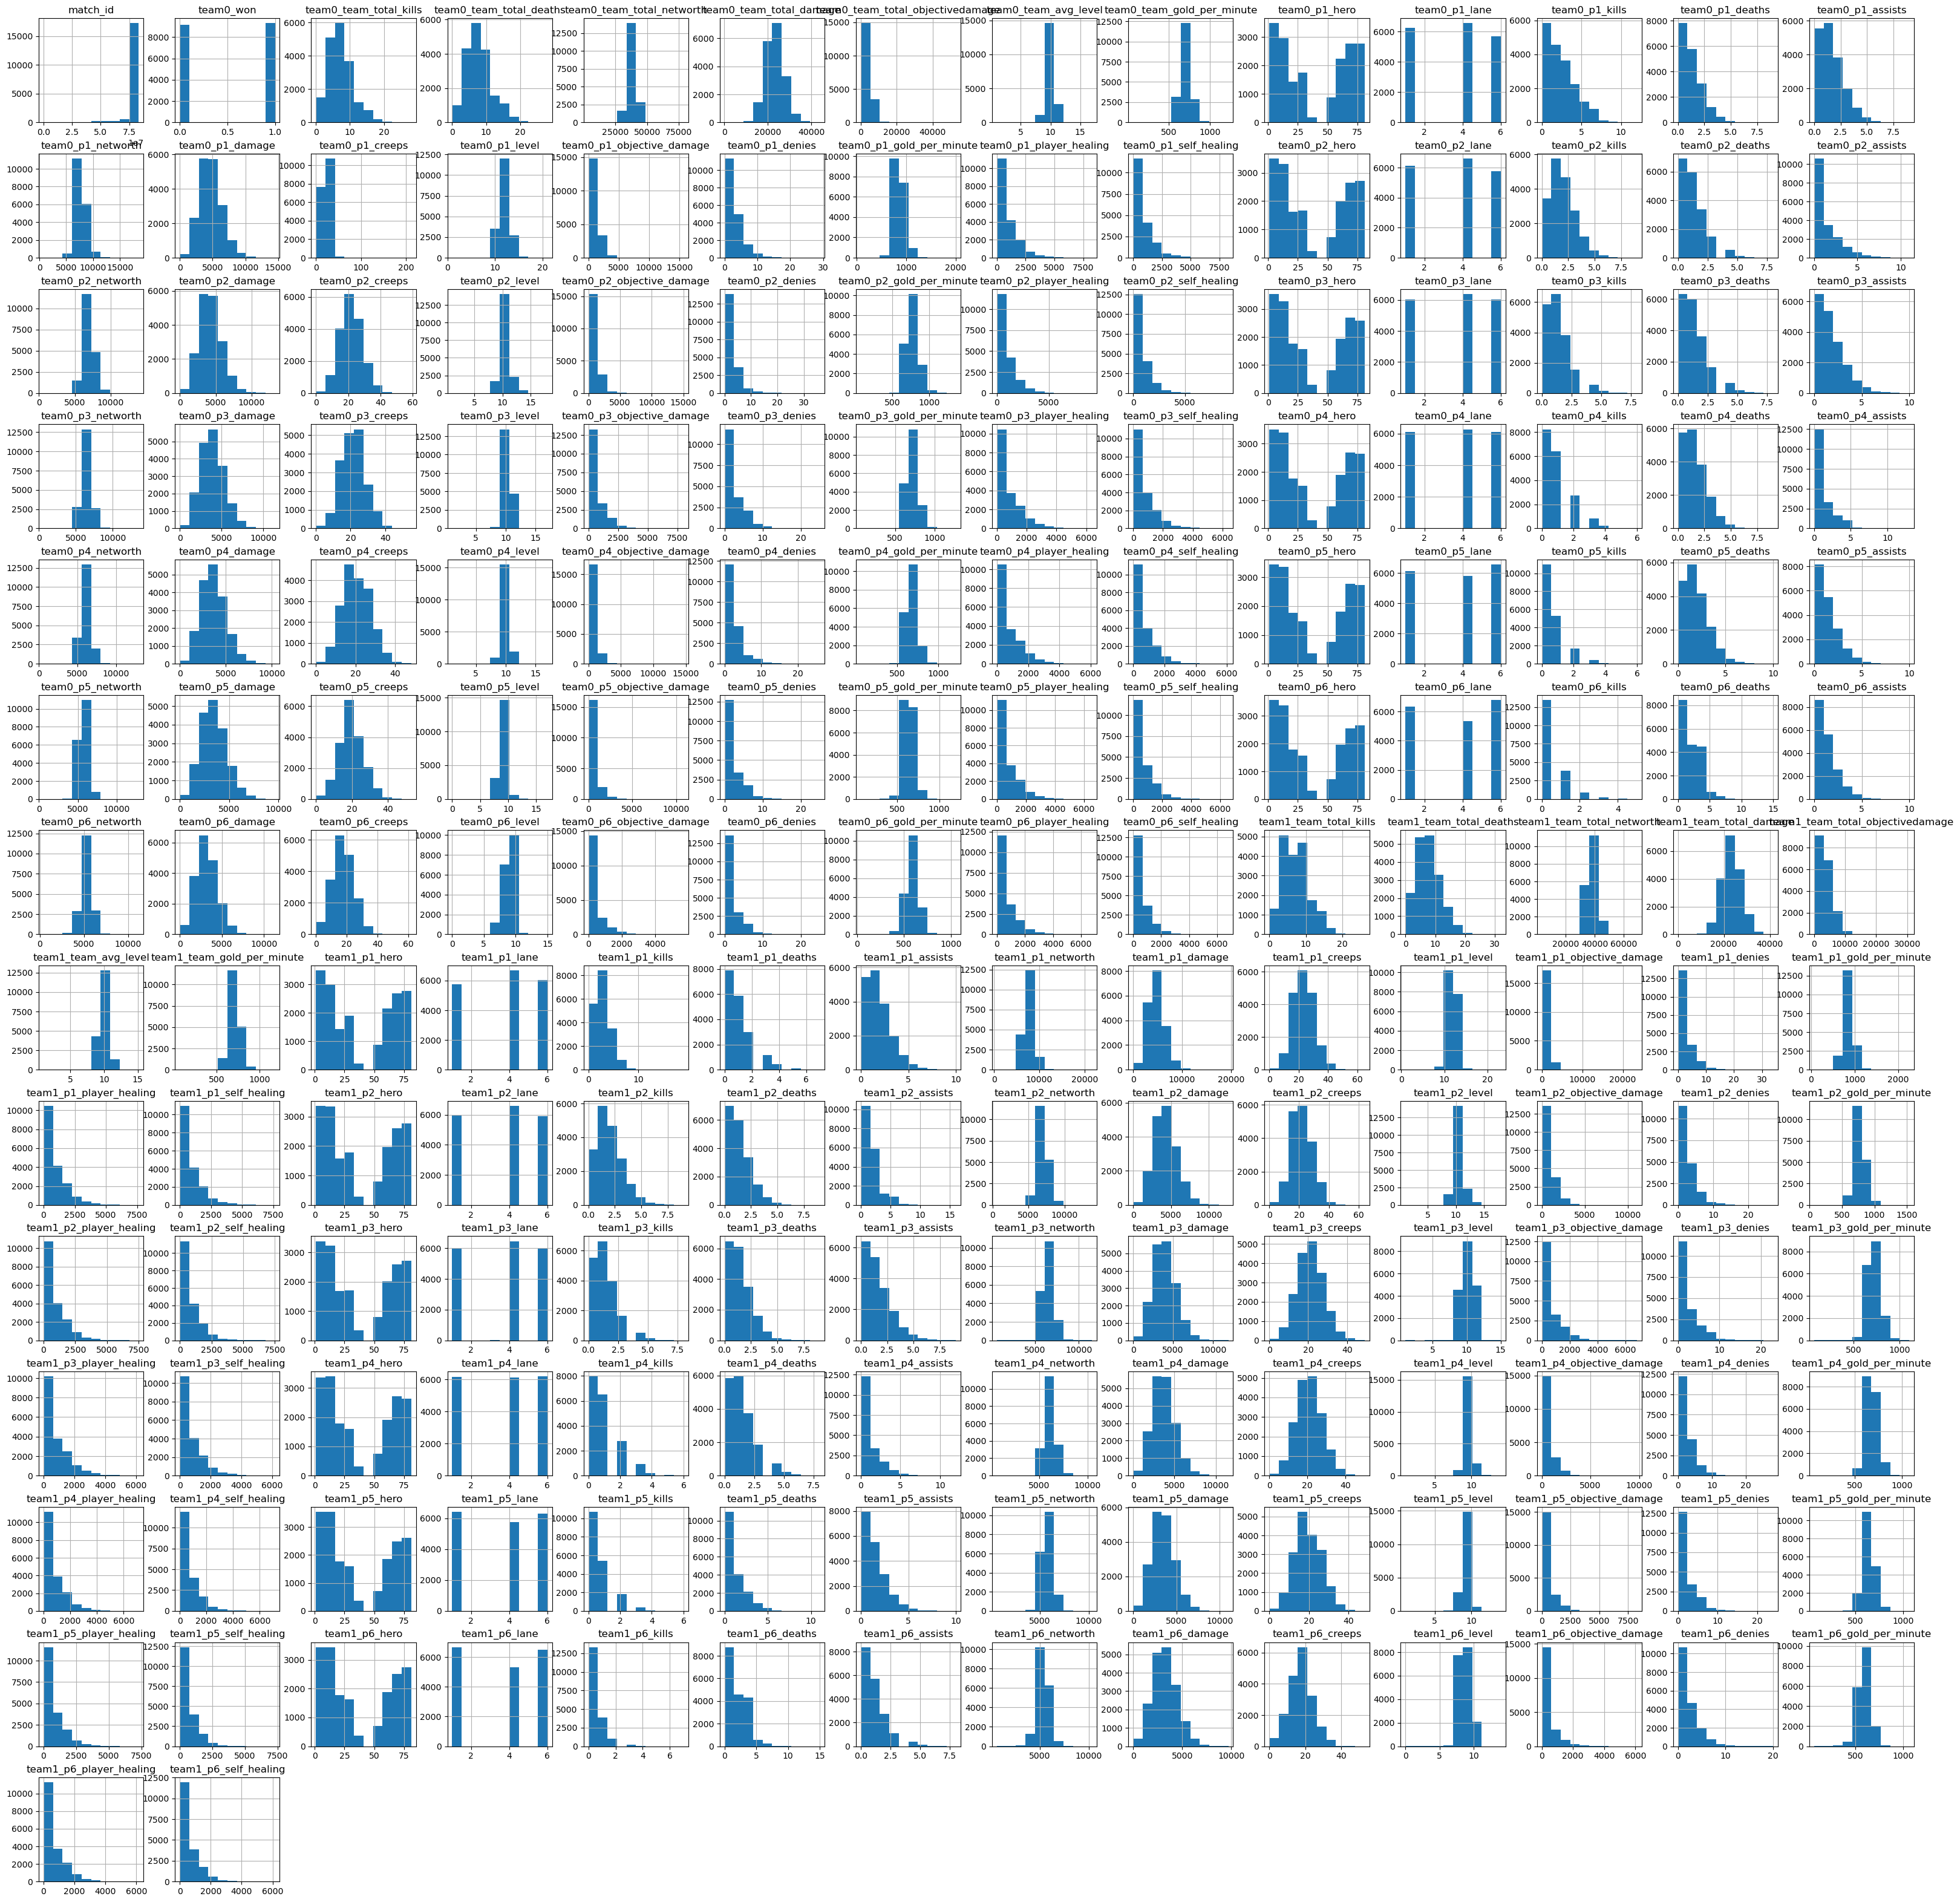

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count    18474.000000
mean     37988.238281
std       3427.740347
min       3900.000000
25%      35698.000000
50%      37759.000000
75%      40037.000000
max      78605.000000
Name: team0_team_total_networth, dtype: float64


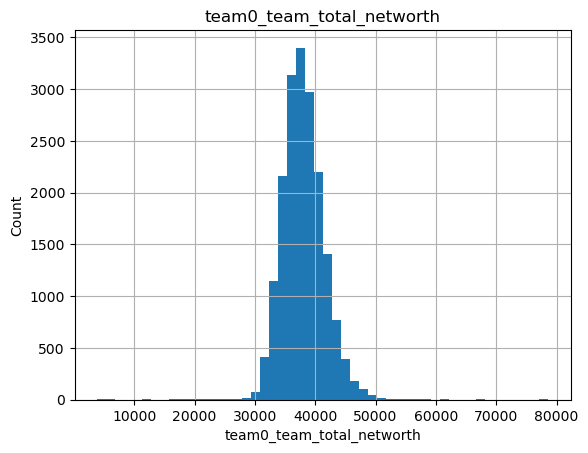

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 60000

count = (df["team0_team_total_networth"] > threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] > 60000]

print((outliers.head(20)))

5
       match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
1389   76431603          1                      15                        4   
2159   80090242          1                       8                        7   
4145   81974507          1                       8                        6   
6627   82560438          1                      21                        8   
10932  82757682          1                      17                        4   

       team0_team_total_networth  team0_team_total_damage  \
1389                       61690                    25787   
2159                       66750                    17144   
4145                       60895                    17741   
6627                       78605                    37406   
10932                      67313                    27793   

       team0_team_total_objectivedamage  team0_team_avg_level  \
1389                              11905             14.333333   
2159                      

# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                           1.000000
team0_team_gold_per_minute          0.239296
team0_team_total_networth           0.239016
team0_team_avg_level                0.230297
team0_team_total_kills              0.208039
                                      ...   
team1_team_total_objectivedamage   -0.195459
team1_team_total_kills             -0.198972
team1_team_avg_level               -0.209041
team1_team_gold_per_minute         -0.216796
team1_team_total_networth          -0.216911
Name: team0_won, Length: 184, dtype: float64
